# Regression Metrics

In [1]:
import pandas as pd
import numpy as np

ames_housing = pd.read_csv("data/house_prices.csv")
data = ames_housing.drop(columns="SalePrice")
target = ames_housing["SalePrice"]
data = data.select_dtypes(np.number)
target /= 1000

In [2]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

- Some machine learning models are designed to be solved as an optimization problem: minimizing an error (also known as the loss function) using a training set. A basic loss function used in regression is the mean squared error (MSE). Thus, this metric is sometimes used to evaluate the model since it is optimized by said model.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

regressor = LinearRegression()
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_train)

print(
    "Mean squared error on the training set: "
    f"{mean_squared_error(target_train, target_predicted):.3f}"
)

Mean squared error on the training set: 996.902


In [4]:
target_predicted = regressor.predict(data_test)

print(
    "Mean squared error on the testing set: "
    f"{mean_squared_error(target_test, target_predicted):.3f}"
)

Mean squared error on the testing set: 2064.736


- The raw MSE can be difficult to interpret. One way is to rescale the MSE by the variance of the target. 
- This score is known as the  𝑅<sup>2</sup> also called the coefficient of determination
- It is the default score in sdi-kit learn when using regressor

In [5]:
regressor.score(data_test, target_test)

0.6872520581075505

In [6]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor.fit(data_train, target_train)
print(
    "R2 score for a regressor predicting the mean:"
    f"{dummy_regressor.score(data_test, target_test):.3f}"
)

R2 score for a regressor predicting the mean:-0.000


In [7]:
from sklearn.metrics import mean_absolute_error

target_predicted = regressor.predict(data_test)
print(
    "Mean absolute error: "
    f"{mean_absolute_error(target_test, target_predicted):.3f} k$"
)

Mean absolute error: 22.608 k$


In [8]:
from sklearn.metrics import median_absolute_error

print(
    "Median absolute error: "
    f"{median_absolute_error(target_test, target_predicted):.3f} k$"
)

Median absolute error: 14.137 k$


In [9]:
from sklearn.metrics import mean_absolute_percentage_error

print(
    "Mean absolute percentage error: "
    f"{mean_absolute_percentage_error(target_test, target_predicted) * 100:.3f} %"
)

Mean absolute percentage error: 13.574 %


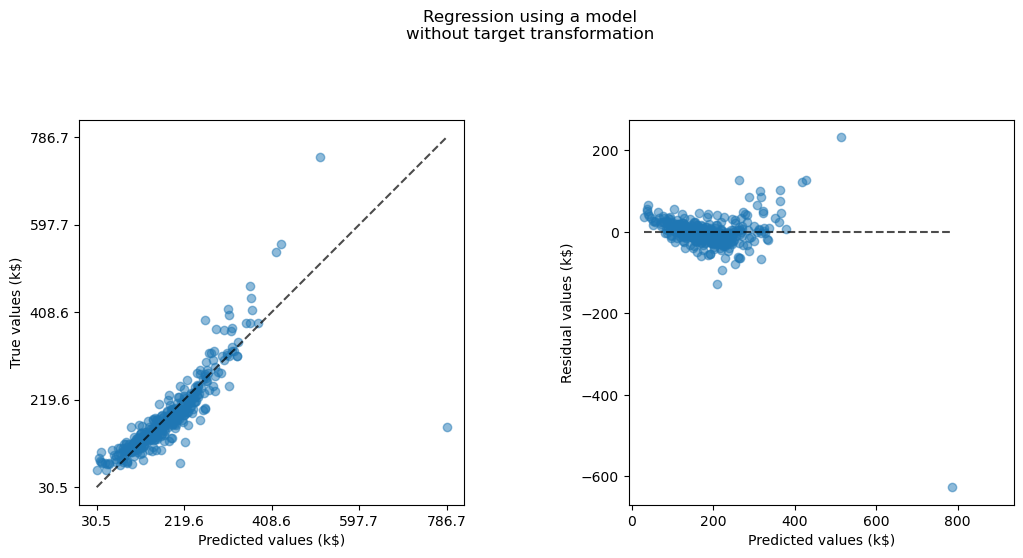

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(13, 5))

PredictionErrorDisplay.from_predictions(
    y_true=target_test,
    y_pred=target_predicted,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[0],
)
axs[0].axis("square")
axs[0].set_xlabel("Predicted values (k$)")
axs[0].set_ylabel("True values (k$)")

PredictionErrorDisplay.from_predictions(
    y_true=target_test,
    y_pred=target_predicted,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[1],
)
axs[1].axis("square")
axs[1].set_xlabel("Predicted values (k$)")
axs[1].set_ylabel("Residual values (k$)")

_ = fig.suptitle(
    "Regression using a model\nwithout target transformation", y=1.1
)

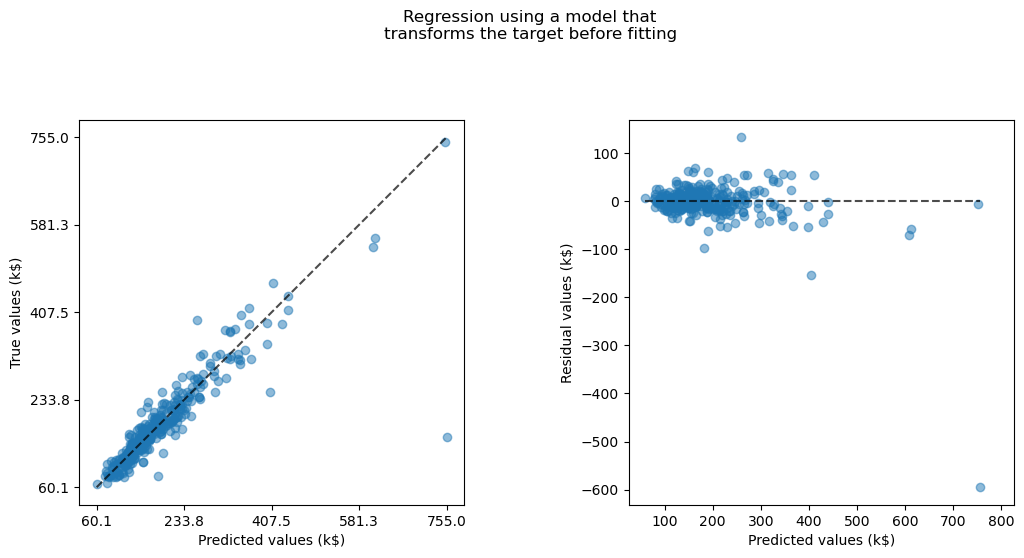

In [11]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor

transformer = QuantileTransformer(
    n_quantiles=900, output_distribution="normal"
)
model_transformed_target = TransformedTargetRegressor(
    regressor=regressor, transformer=transformer
)
model_transformed_target.fit(data_train, target_train)
target_predicted = model_transformed_target.predict(data_test)

fig, axs = plt.subplots(ncols=2, figsize=(13, 5))

PredictionErrorDisplay.from_predictions(
    y_true=target_test,
    y_pred=target_predicted,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[0],
)
axs[0].axis("square")
axs[0].set_xlabel("Predicted values (k$)")
axs[0].set_ylabel("True values (k$)")

PredictionErrorDisplay.from_predictions(
    y_true=target_test,
    y_pred=target_predicted,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[1],
)
axs[1].axis("square")
axs[1].set_xlabel("Predicted values (k$)")
axs[1].set_ylabel("Residual values (k$)")

_ = fig.suptitle(
    "Regression using a model that\ntransforms the target before fitting",
    y=1.1,
)

In [12]:
print(
    "Mean absolute error: "
    f"{mean_absolute_error(target_test, target_predicted):.3f} k$"
)
print(
    "Median absolute error: "
    f"{median_absolute_error(target_test, target_predicted):.3f} k$"
)
print(
    "Mean absolute percentage error: "
    f"{mean_absolute_percentage_error(target_test, target_predicted):.2%}"
)

Mean absolute error: 17.406 k$
Median absolute error: 10.327 k$
Mean absolute percentage error: 9.92%
